# 3D Grounding-DETR Visualization Demo

This notebook demonstrates how to visualize predictions from the 3D Grounding-DETR model on CT volumes.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from models import build_model
from datasets import RSNAVolumeDataset
from utils.visualization import (
    visualize_single_slice,
    visualize_multi_slice,
    save_visualization
)
from utils.metrics import compute_map

%matplotlib inline

## 1. Load Model and Dataset

In [ ]:
# Configuration
CHECKPOINT_PATH = 'checkpoints/model_best.pth'
DATA_DIR = './datasets'
SAMPLE_IDX = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# Load checkpoint
print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
config = checkpoint['config']

# Build model
print("Building model...")
model = build_model(config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

Loading checkpoint from checkpoints/model_best.pth...
Building model...
Model built with 42,147,948 parameters
Model loaded successfully!


/Users/siqichen/miniconda3/envs/openmmlab/lib/python3.8/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [4]:
# Load dataset
print(f"Loading dataset from {DATA_DIR}...")
dataset = RSNAVolumeDataset(
    data_dir=DATA_DIR,
    volume_size=tuple(config['data']['image_size']),
    train=False,
    augment=False
)

print(f"Dataset size: {len(dataset)}")

Loading dataset from ./datasets...
Found 2 segmentation files
Dataset size: 2


## 2. Run Inference

In [5]:
# Get sample
sample = dataset[SAMPLE_IDX]
volume = sample['volume']  # (1, D, H, W)
series_id = sample['study_id']
gt_boxes = sample['boxes'].numpy()
gt_labels = sample['labels'].numpy()

print(f"series ID: {series_id}")
print(f"Volume shape: {volume.shape}")
print(f"Ground truth objects: {len(gt_boxes)}")

series ID: 21057
Volume shape: torch.Size([1, 64, 64, 64])
Ground truth objects: 6


In [6]:
# Run inference
print("Running inference...")
with torch.no_grad():
    volume_input = volume.unsqueeze(0).to(DEVICE).float()  # (1, 1, D, H, W)
    outputs = model(volume_input)
    
    pred_logits = outputs['pred_logits'][0]  # (num_queries, num_classes+1)
    pred_boxes = outputs['pred_boxes'][0]    # (num_queries, 6)
    
    # Get scores and labels
    pred_scores = pred_logits.softmax(-1)
    pred_labels = pred_scores[:, :-1].argmax(-1)  # Exclude background
    pred_scores = pred_scores.max(-1)[0]
    
    # Move to CPU
    pred_boxes = pred_boxes.cpu().numpy()
    pred_labels = pred_labels.cpu().numpy()
    pred_scores = pred_scores.cpu().numpy()

print("Inference complete!")

Running inference...
Inference complete!


In [7]:
# Filter predictions by score threshold
SCORE_THRESHOLD = 0.95

valid_mask = pred_scores >= SCORE_THRESHOLD
pred_boxes_filtered = pred_boxes[valid_mask]
pred_labels_filtered = pred_labels[valid_mask]
pred_scores_filtered = pred_scores[valid_mask]

print(f"Predictions (score >= {SCORE_THRESHOLD}): {len(pred_boxes_filtered)}")
for i, (box, label, score) in enumerate(zip(pred_boxes_filtered, pred_labels_filtered, pred_scores_filtered)):
    print(f"  {i+1}. Class {label}, Score: {score:.3f}")

Predictions (score >= 0.95): 5
  1. Class 3, Score: 0.990
  2. Class 2, Score: 0.995
  3. Class 1, Score: 0.993
  4. Class 4, Score: 0.990
  5. Class 4, Score: 0.992


## 3. Single-Slice Visualization

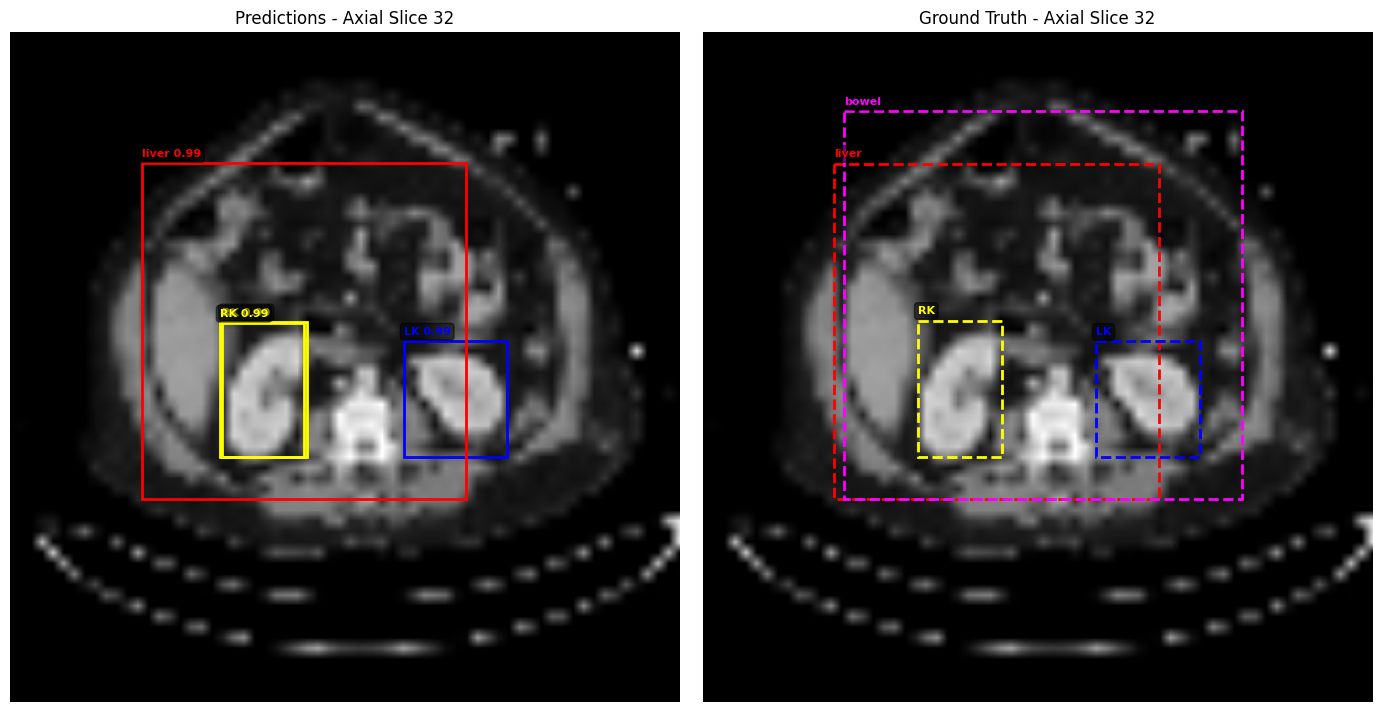

In [8]:
# Visualize middle slice
volume_np = volume[0].numpy()  # Remove channel dimension
middle_slice = volume_np.shape[0] // 2

fig = visualize_single_slice(
    volume_np,
    slice_idx=middle_slice,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    axis='axial',
    score_threshold=SCORE_THRESHOLD,
    figsize=(14, 7)
)

plt.show()

## 4. Multi-Slice Visualization (Axial & Sagittal & Coronal)

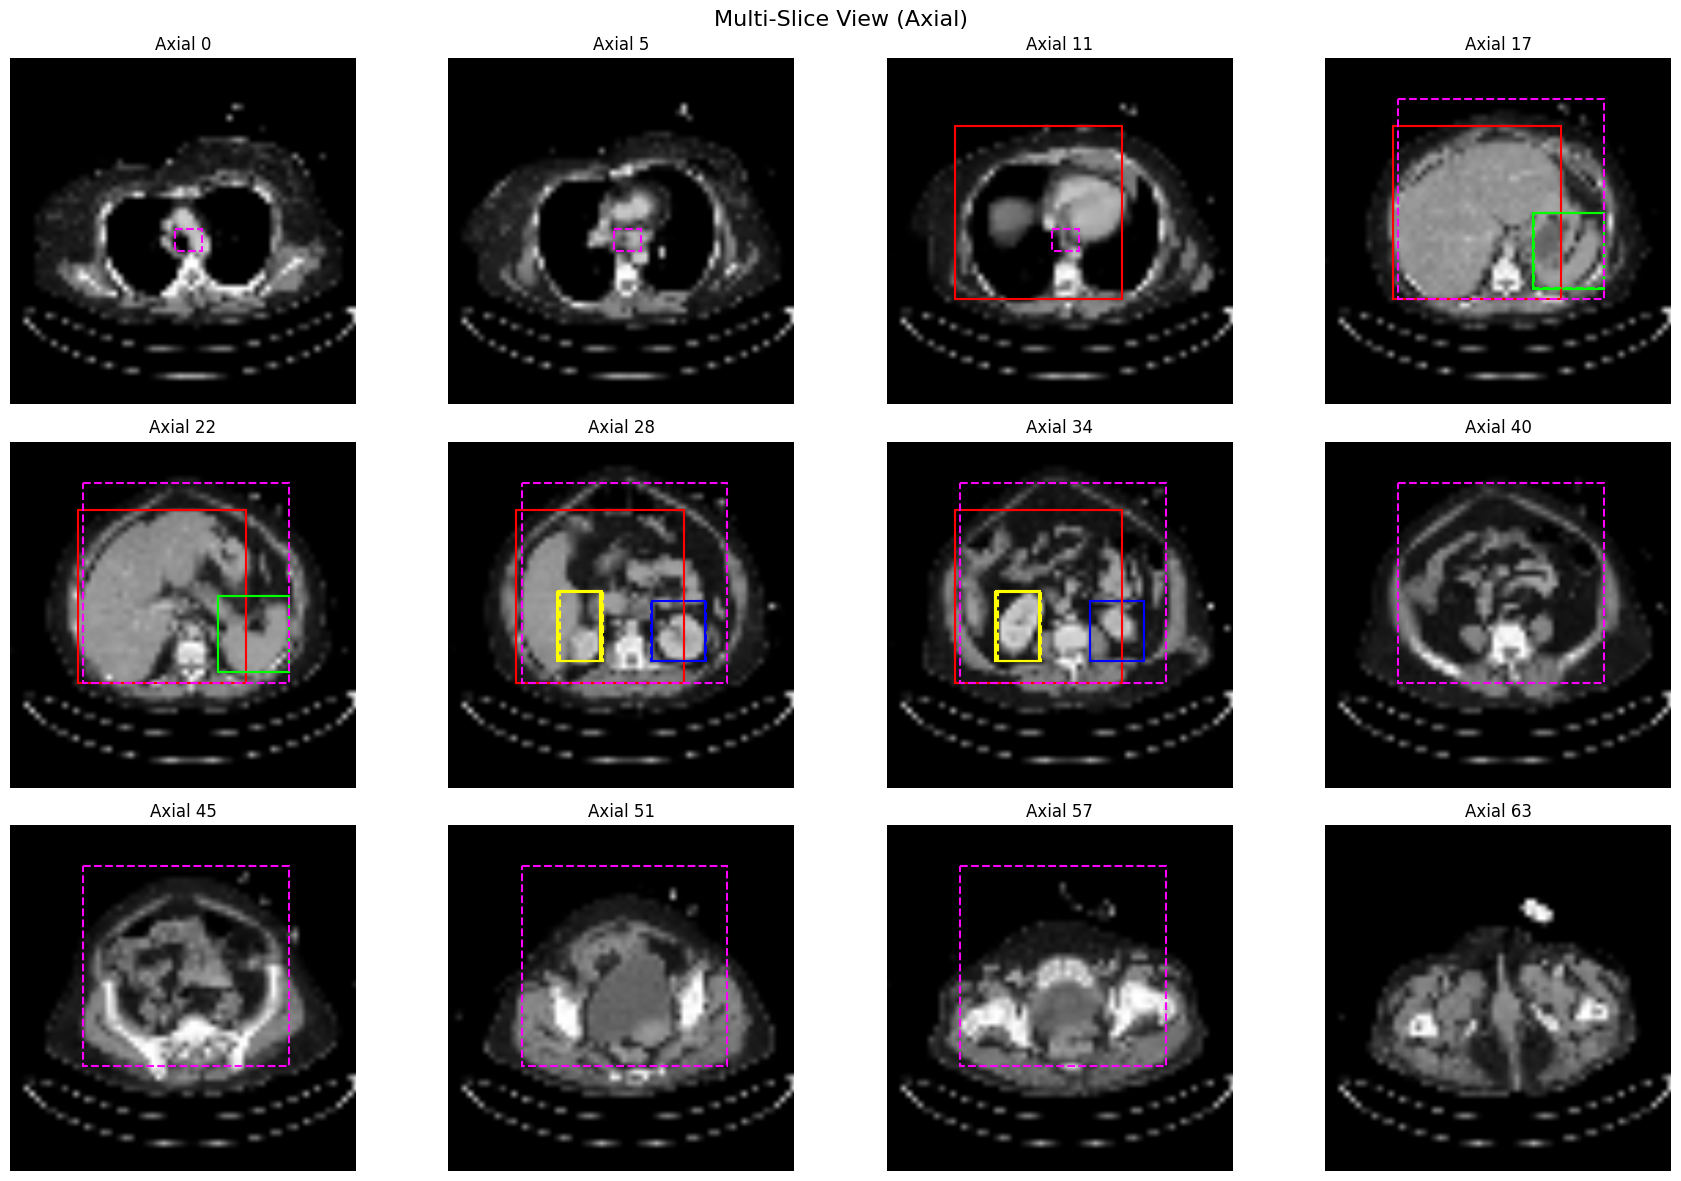

In [9]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='axial',
    score_threshold=SCORE_THRESHOLD,
    figsize=(18, 12)
)

plt.show()

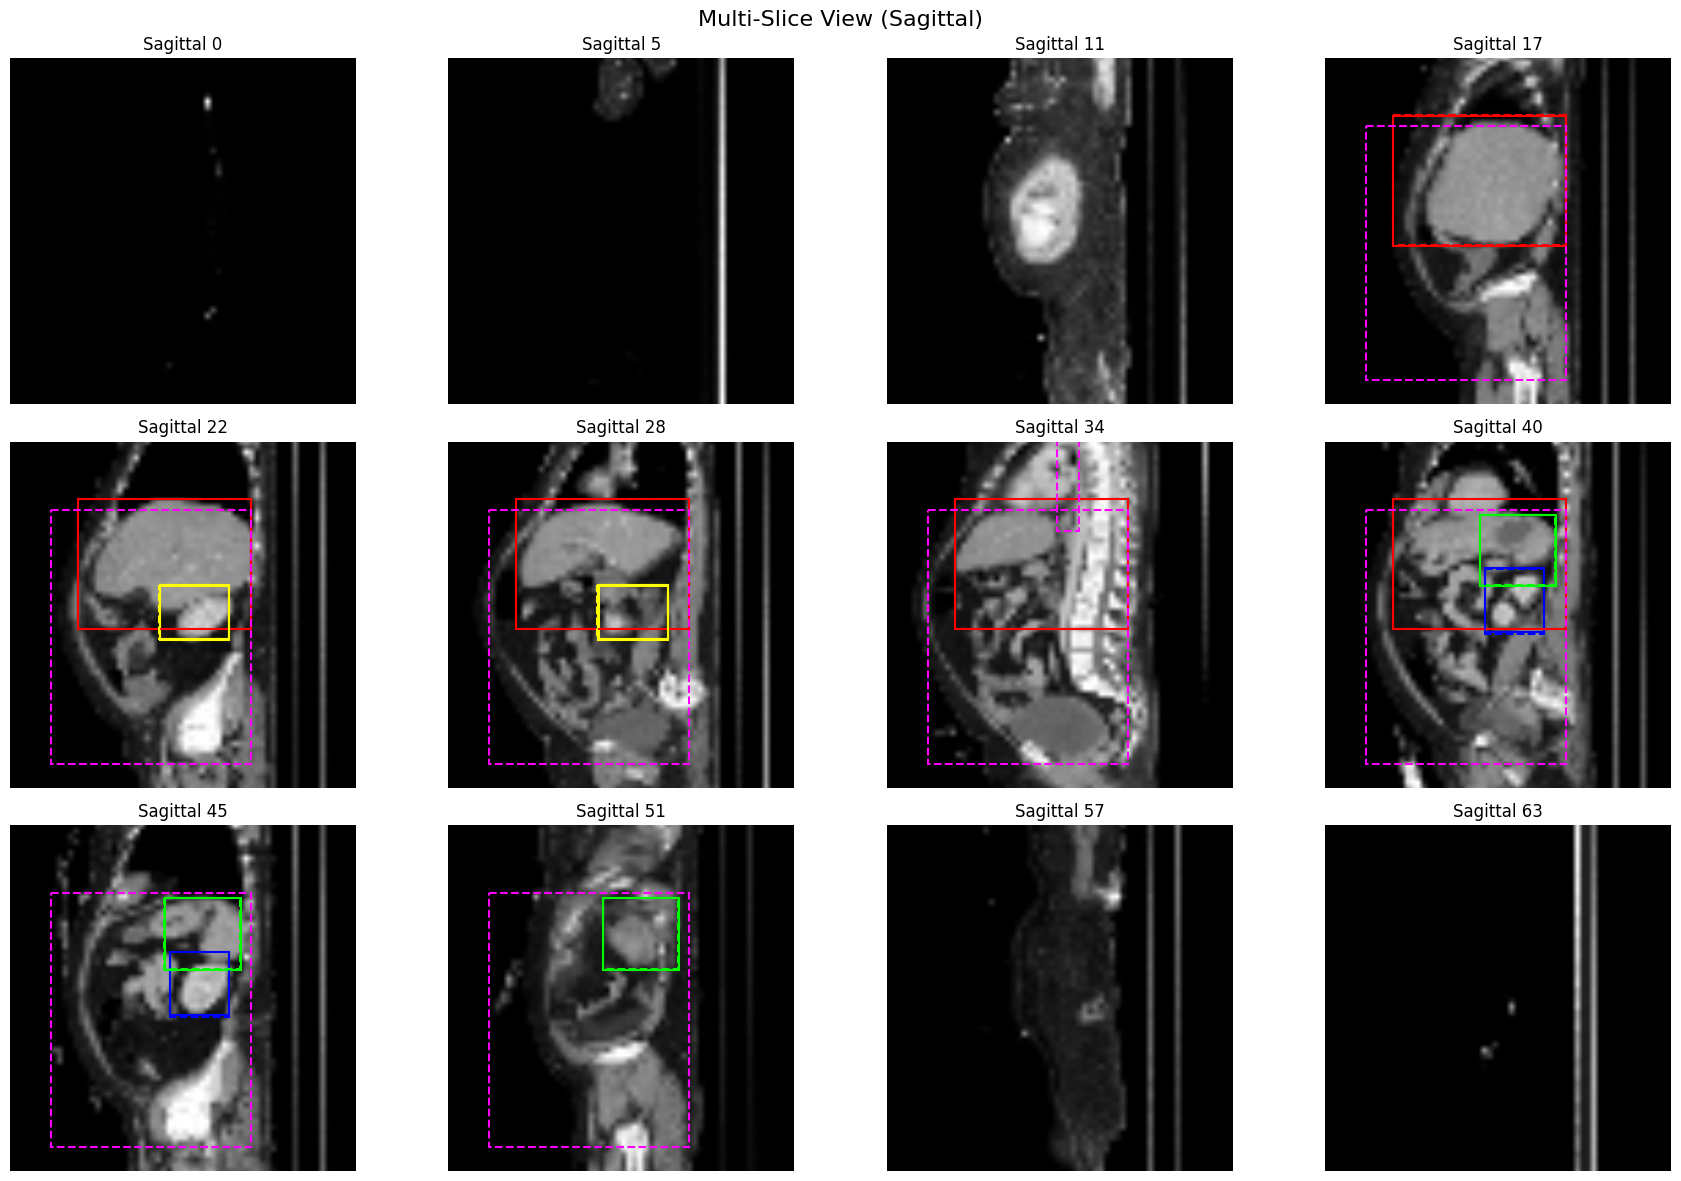

In [10]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='sagittal',
    score_threshold=SCORE_THRESHOLD,
    figsize=(18, 12)
)

plt.show()

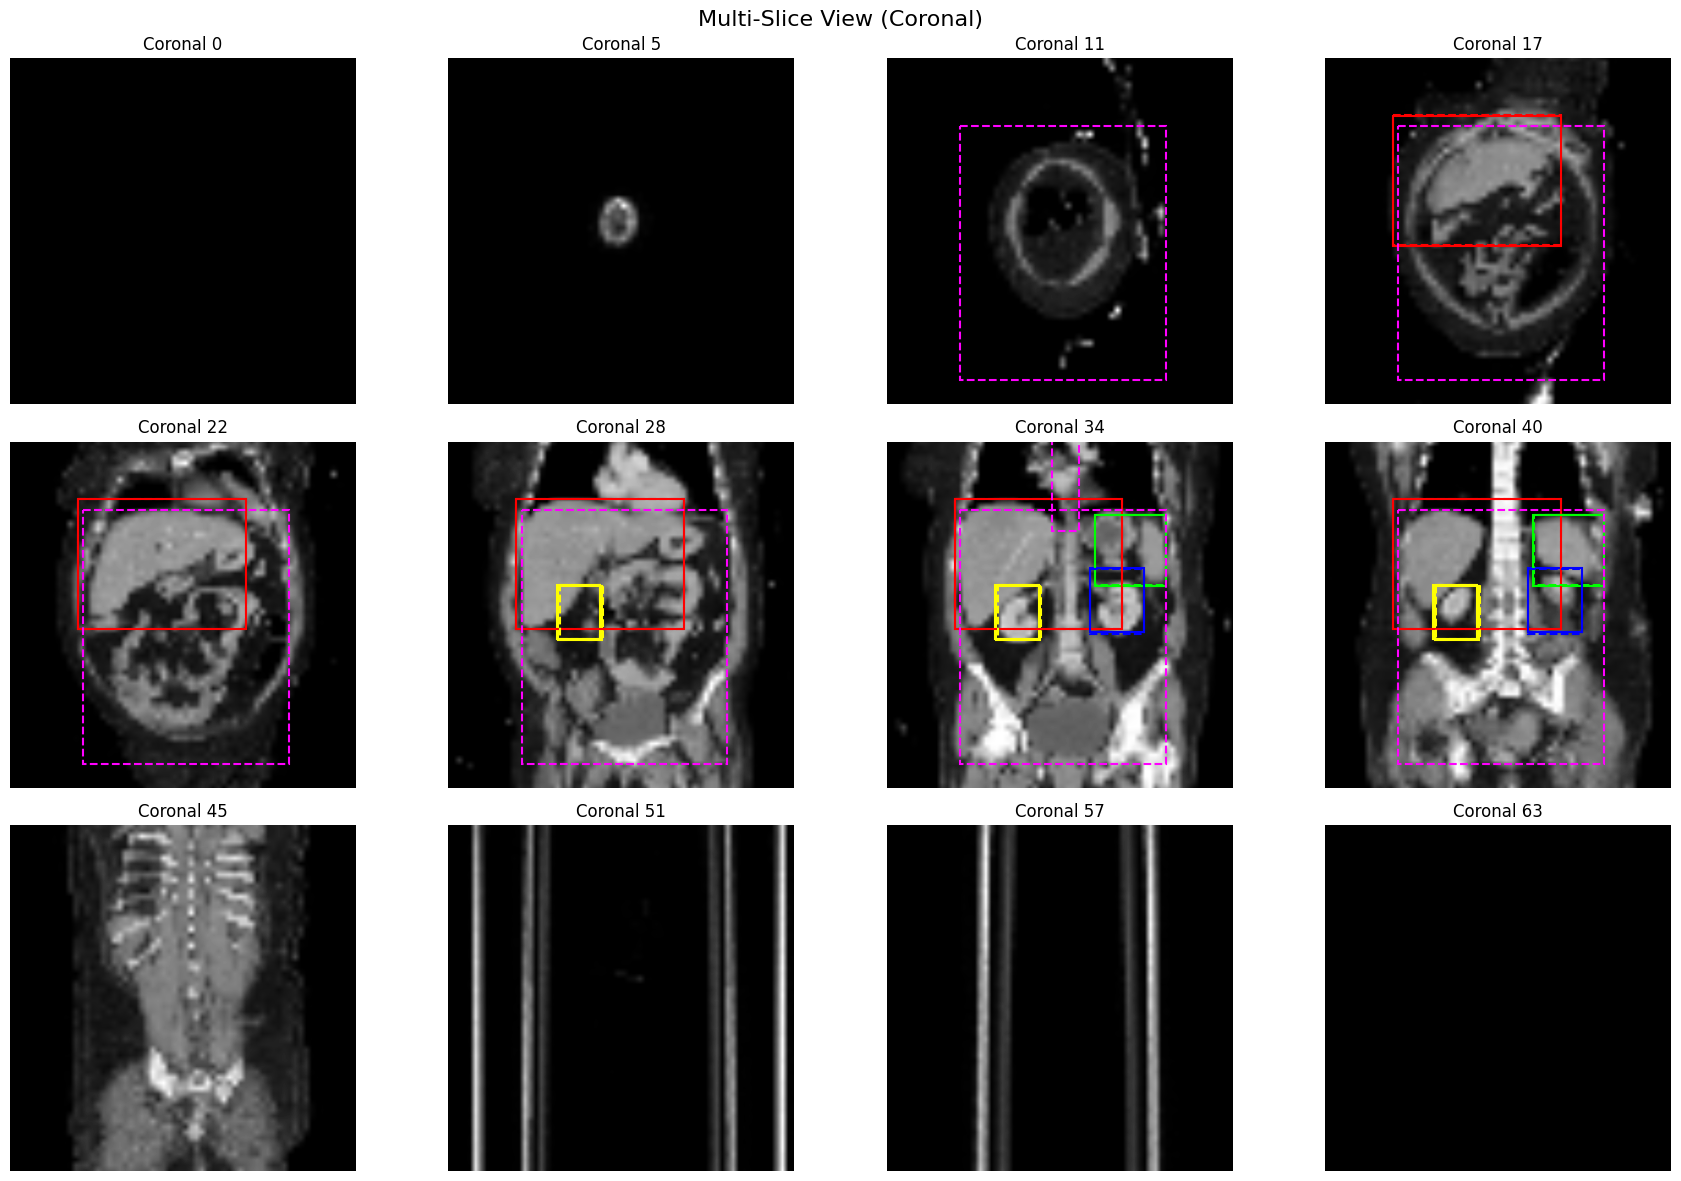

In [11]:
# Visualize multiple slices
fig = visualize_multi_slice(
    volume_np,
    pred_boxes=pred_boxes_filtered.tolist() if len(pred_boxes_filtered) > 0 else None,
    pred_labels=pred_labels_filtered.tolist() if len(pred_labels_filtered) > 0 else None,
    pred_scores=pred_scores_filtered.tolist() if len(pred_scores_filtered) > 0 else None,
    gt_boxes=gt_boxes.tolist(),
    gt_labels=gt_labels.tolist(),
    num_slices=12,
    axis='coronal',
    score_threshold=SCORE_THRESHOLD,
    figsize=(18, 12)
)

plt.show()

## 5. Calculate mAP (Mean Average Precision)

In [12]:
# Prepare predictions and ground truths in the format required by compute_map
# The function expects a list of dictionaries

predictions = [{
    'boxes': pred_boxes,  # All predictions (not filtered)
    'scores': pred_scores,
    'labels': pred_labels
}]

ground_truths = [{
    'boxes': gt_boxes,
    'labels': gt_labels
}]

# Number of classes in your dataset
num_classes = config['model']['num_classes']

print(f"Number of classes: {num_classes}")
print(f"Predictions: {len(pred_boxes)} boxes")
print(f"Ground truths: {len(gt_boxes)} boxes")

Number of classes: 5
Predictions: 10 boxes
Ground truths: 6 boxes


In [13]:
# Compute mAP at different IoU thresholds
iou_thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

map_results = compute_map(
    predictions=predictions,
    ground_truths=ground_truths,
    num_classes=num_classes,
    iou_thresholds=iou_thresholds
)

print("\n" + "="*50)
print("mAP Results:")
print("="*50)
for metric_name, value in map_results.items():
    print(f"{metric_name}: {value:.4f}")
print("="*50)


mAP Results:
mAP@0.1: 0.0000
mAP@0.3: 0.0000
mAP@0.5: 0.0000
mAP@0.7: 0.0000
mAP@0.9: 0.1250
mAP: 0.0250


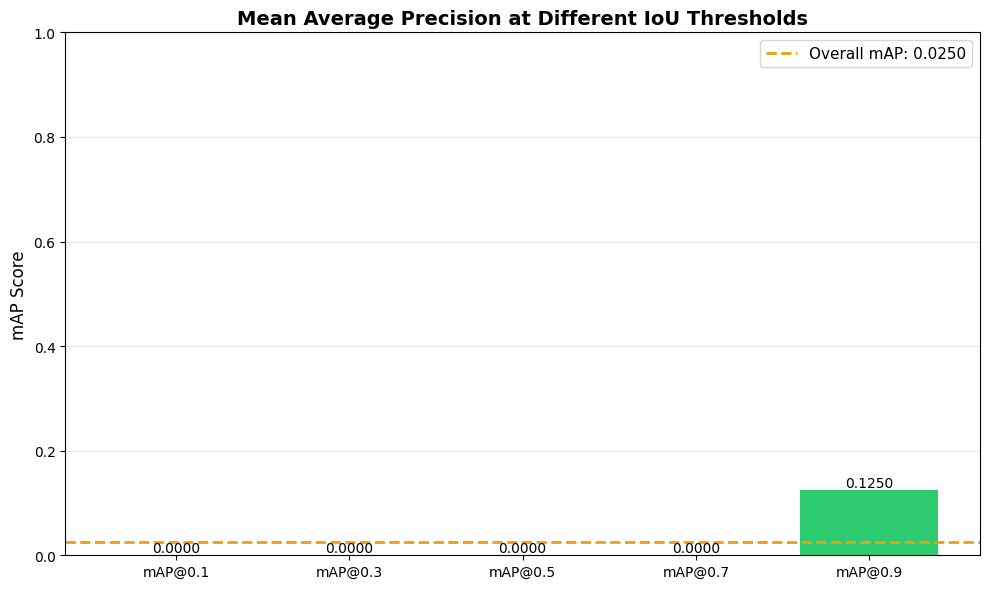

In [14]:
# Visualize mAP results
import matplotlib.pyplot as plt

# Create a bar plot
metrics = [k for k in map_results.keys() if k != 'mAP']
values = [map_results[k] for k in metrics]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.axhline(y=map_results['mAP'], color='#f39c12', linestyle='--', 
           linewidth=2, label=f"Overall mAP: {map_results['mAP']:.4f}")

ax.set_ylabel('mAP Score', fontsize=12)
ax.set_title('Mean Average Precision at Different IoU Thresholds', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Evaluate mAP on multiple samples
NUM_SAMPLES_TO_EVAL = min(10, len(dataset))  # Evaluate on 10 samples or fewer

all_predictions = []
all_ground_truths = []

print(f"Evaluating on {NUM_SAMPLES_TO_EVAL} samples...")

for idx in range(NUM_SAMPLES_TO_EVAL):
    sample = dataset[idx]
    volume = sample['volume']
    
    # Run inference
    with torch.no_grad():
        volume_input = volume.unsqueeze(0).to(DEVICE).float()
        outputs = model(volume_input)
        
        pred_logits = outputs['pred_logits'][0]
        pred_boxes = outputs['pred_boxes'][0]
        
        pred_scores = pred_logits.softmax(-1)
        pred_labels = pred_scores[:, :-1].argmax(-1)
        pred_scores = pred_scores.max(-1)[0]
        
        # Store predictions
        all_predictions.append({
            'boxes': pred_boxes.cpu().numpy(),
            'scores': pred_scores.cpu().numpy(),
            'labels': pred_labels.cpu().numpy()
        })
        
    # Store ground truths
    all_ground_truths.append({
        'boxes': sample['boxes'].numpy(),
        'labels': sample['labels'].numpy()
    })

# Compute mAP on all samples
multi_sample_map = compute_map(
    predictions=all_predictions,
    ground_truths=all_ground_truths,
    num_classes=num_classes,
    iou_thresholds=iou_thresholds
)

print("\n" + "="*50)
print(f"mAP Results on {NUM_SAMPLES_TO_EVAL} Samples:")
print("="*50)
for metric_name, value in multi_sample_map.items():
    print(f"{metric_name}: {value:.4f}")
print("="*50)

Evaluating on 2 samples...

mAP Results on 2 Samples:
mAP@0.1: 0.5000
mAP@0.3: 0.5000
mAP@0.5: 0.5000
mAP@0.7: 0.2500
mAP@0.9: 0.0417
mAP: 0.3583
